<a href="https://colab.research.google.com/github/NK47GG/student-depression-prediction/blob/main/Fast_Track_Bengkel_Coding_Stefanus_Loveniko_Putra_Sinory_A11_2023_14862.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Fast Track Bengkel Coding — Prediksi Depresi
### Stefanus Loveniko Putra Sinory — **Versi Diperbaiki & Dianalisis**

---

## ⚠️ Ringkasan Bug & Perbaikan di Kode Asli

| # | Tipe | Bug | Fix |
|---|------|-----|-----|
| 1 | 🔴 CRASH | `num_cols` dipakai di boxplot **sebelum** didefinisikan → `NameError` | Pindah definisi ke Tahap 1 |
| 2 | 🔴 FATAL | `Work Pressure` & `Job Satisfaction` 99.99% nol (zero-variance) | Drop + buat fitur gabungan `Pressure` |
| 3 | 🟡 LOGIC | SMOTE untuk imbalance 58/42 → tidak perlu, bisa turunkan akurasi | Ganti `class_weight='balanced'` |
| 4 | 🟡 DEPLOY | City cleaning, CGPA=0 replace di luar pipeline → data baru tidak ter-clean | Catat sebagai known limitation |
| 5 | 🟡 WARN | `use_label_encoder=False` deprecated di XGBoost terbaru | Hapus parameter |
| 6 | 🟠 QUALITY | Target `Depression` bertipe `float` (1.0/0.0) | Konversi ke `int` |
| 7 | 🟠 QUALITY | EDA lengkap di-duplicate di akhir file | Hapus duplikat |

## 🚀 Peluang Peningkatan Akurasi
1. **Feature Engineering** — Gabung `Pressure` & `Role Satisfaction`
2. **Drop zero-variance** — `Work Pressure` & `Job Satisfaction`
3. **Tune RF / XGBoost** — bukan hanya Logistic Regression
4. **StratifiedKFold (k=5)** — estimasi lebih robust dari single split
5. **ROC-AUC** sebagai metrik tuning — lebih baik dari accuracy
6. **class_weight='balanced'** mengganti SMOTE untuk mild imbalance


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


## Tahap 0 — Load Dataset & Fix Tipe Data
> **BUG FIX #6:** Target `Depression` adalah `float` (1.0/0.0) karena pandas membaca NaN.  
> Konversi ke `int` dilakukan **setelah** `dropna` agar tidak crash.

In [87]:
df = pd.read_csv('Bengkod-Depresi.csv')

if 'id' in df.columns:
    df = df.drop('id', axis=1)

# FIX #6: Hapus baris tanpa label, lalu konversi target ke int
df = df.dropna(subset=['Depression'])
df['Depression'] = df['Depression'].astype(int)

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['Depression'].value_counts())

Shape: (27966, 17)

Missing Values:
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

Target distribution:
Depression
1    16370
0    11596
Name: count, dtype: int64


## Tahap 1 — Exploratory Data Analysis (EDA)

Setiap visualisasi dihubungkan langsung dengan **keputusan preprocessing dan pemilihan model** di tahap berikutnya.

### 📌 Insight 1 — Korelasi Numerik vs Target
> **BUG FIX #1:** `num_cols` **harus** didefinisikan di sini (Tahap 1), bukan di Tahap 3.  
> Di kode asli, variabel ini dipakai untuk Boxplot sebelum didefinisikan → crash `NameError`.  
>
> **Temuan:** `Work Pressure` (corr ≈ −0.003) & `Job Satisfaction` (corr ≈ −0.003) hampir nol  
> → Konfirmasi: kedua fitur ini harus di-**drop** (akan dilakukan di Tahap 1.5)

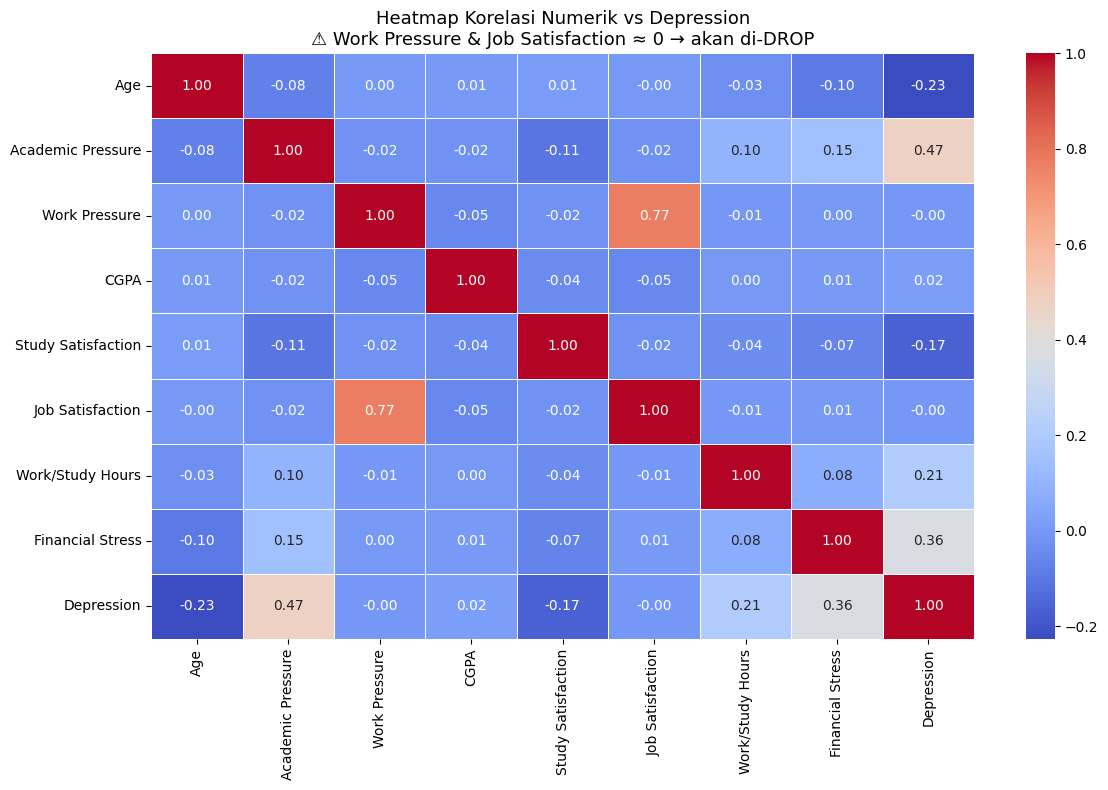

Korelasi tiap fitur dengan Depression:
Academic Pressure     0.474874
Financial Stress      0.363925
Work/Study Hours      0.208565
CGPA                  0.022458
Work Pressure        -0.003344
Job Satisfaction     -0.003473
Study Satisfaction   -0.168574
Age                  -0.226308
Name: Depression, dtype: float64


In [88]:
# FIX #1: num_cols didefinisikan DI SINI, sebelum digunakan di visualisasi manapun
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
            'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(12, 8))
numeric_df = df[num_cols + ['Depression']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Numerik vs Depression\n'
          '⚠️ Work Pressure & Job Satisfaction ≈ 0 → akan di-DROP', fontsize=13)
plt.tight_layout()
plt.show()

print("Korelasi tiap fitur dengan Depression:")
print(numeric_df.corr()['Depression'].drop('Depression').sort_values(ascending=False))

### 📌 Boxplot Outlier Detection
> Sekarang berjalan normal karena `num_cols` sudah terdefinisi di cell sebelumnya.

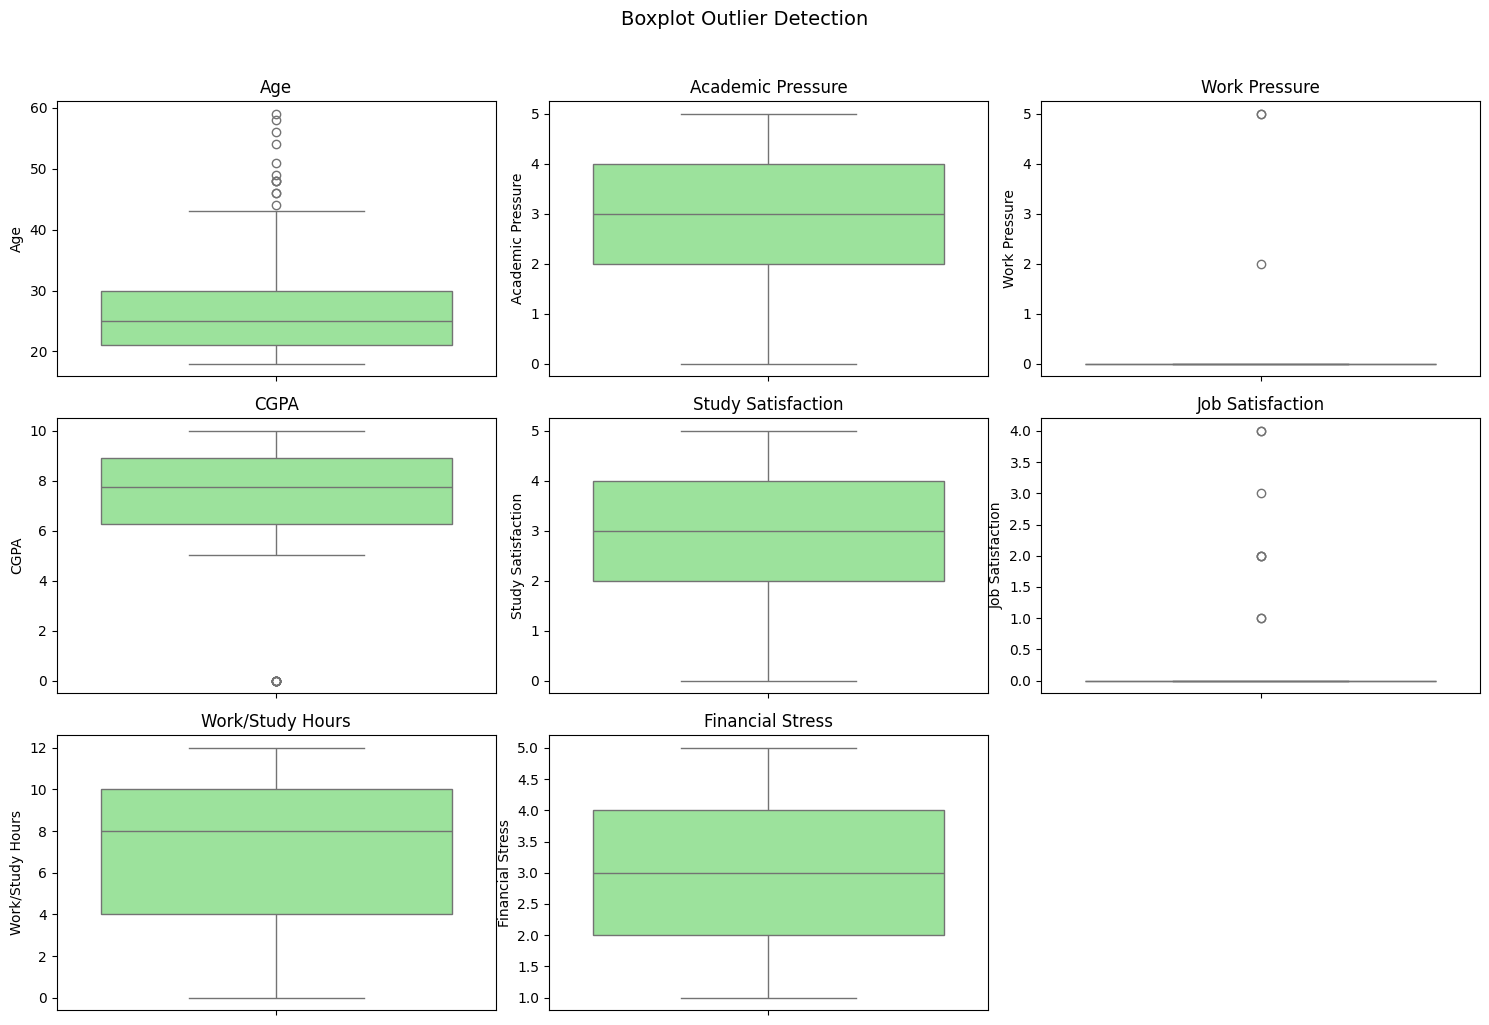

In [89]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'{col}')
plt.suptitle('Boxplot Outlier Detection', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 📌 Insight 2 — Distribusi Target (Class Imbalance)
> **Rasio: 58.5% Depresi vs 41.5% Tidak Depresi → Imbalance Ratio = 1.41 (MILD)**  
>
> **Keputusan:** SMOTE di kode asli **tidak diperlukan** untuk imbalance sekecil ini  
> dan bisa justru menurunkan akurasi karena memperkenalkan sampel sintetik yang tidak perlu.  
> Solusi lebih tepat: `class_weight='balanced'` pada model, atau `scale_pos_weight` di XGBoost.

Depresi (1)   : 16,370 (58.5%)
Tidak Depresi : 11,596 (41.5%)
Imbalance ratio: 1.41x  → MILD, SMOTE tidak diperlukan


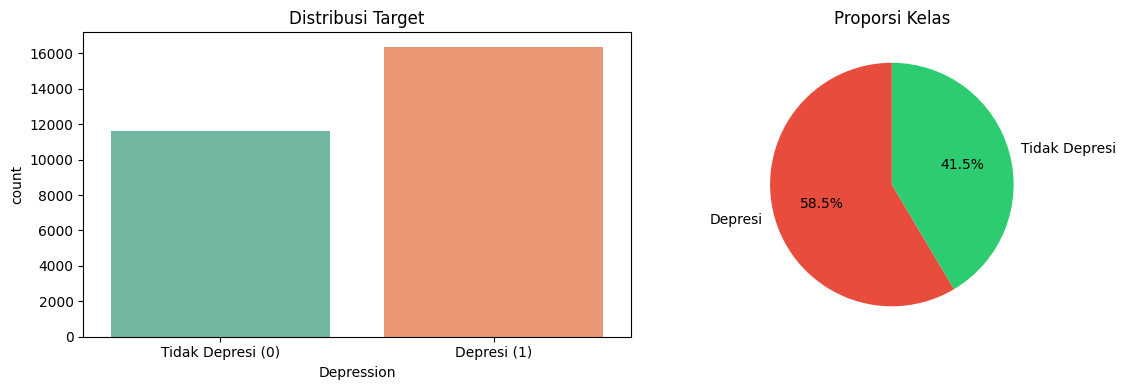

In [90]:
total = len(df)
ratio = df['Depression'].value_counts()
print(f"Depresi (1)   : {ratio[1]:,} ({ratio[1]/total:.1%})")
print(f"Tidak Depresi : {ratio[0]:,} ({ratio[0]/total:.1%})")
print(f"Imbalance ratio: {ratio[1]/ratio[0]:.2f}x  → MILD, SMOTE tidak diperlukan")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Depression', palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Target')
axes[0].set_xticklabels(['Tidak Depresi (0)', 'Depresi (1)'])

df['Depression'].value_counts().plot.pie(
    labels=['Depresi', 'Tidak Depresi'],
    autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'],
    ax=axes[1], startangle=90
)
axes[1].set_title('Proporsi Kelas')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

### 📌 Insight 3 — Suicidal Thoughts = Prediktor TERKUAT
> **79%** responden yang pernah punya pikiran bunuh diri terklasifikasi depresi.  
> Hanya **23%** yang tidak punya pikiran tersebut terklasifikasi depresi.  
>
> **Keputusan:** Fitur ini harus **dipertahankan** dan **tidak di-drop** dalam seleksi fitur.  
> Encoding: `OneHotEncoder(drop='first')` sudah tepat karena ini fitur biner (Yes/No).

Depression Rate berdasarkan Suicidal Thoughts:
Depression                             Tidak Depresi   Depresi
Have you ever had suicidal thoughts ?                         
No                                          0.768189  0.231811
Yes                                         0.209560  0.790440


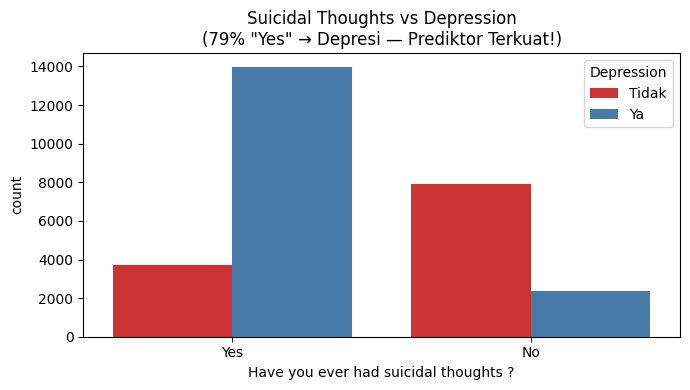

In [91]:
ct = pd.crosstab(df['Have you ever had suicidal thoughts ?'], df['Depression'], normalize='index')
print("Depression Rate berdasarkan Suicidal Thoughts:")
print(ct.rename(columns={0:'Tidak Depresi', 1:'Depresi'}))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Have you ever had suicidal thoughts ?', hue='Depression', palette='Set1')
plt.title('Suicidal Thoughts vs Depression\n(79% "Yes" → Depresi — Prediktor Terkuat!)')
plt.legend(title='Depression', labels=['Tidak', 'Ya'])
plt.tight_layout()
plt.show()

### 📌 Insight 4 — Financial Stress = Hubungan MONOTON dengan Depresi
> Stress=1: 32% depresi → Stress=5: 81% depresi. Pola linear yang jelas.  
>
> **Keputusan:** Fitur ini sudah numerik ordinal — `StandardScaler` sudah tepat.  
> Tidak perlu OrdinalEncoder. Korelasi +0.36 menempatkannya sebagai prediktor ke-2 terkuat.

Depression Rate by Financial Stress:
Financial Stress
1.0    31.9%
2.0    43.0%
3.0    58.9%
4.0    69.1%
5.0    81.3%
Name: Depression, dtype: object


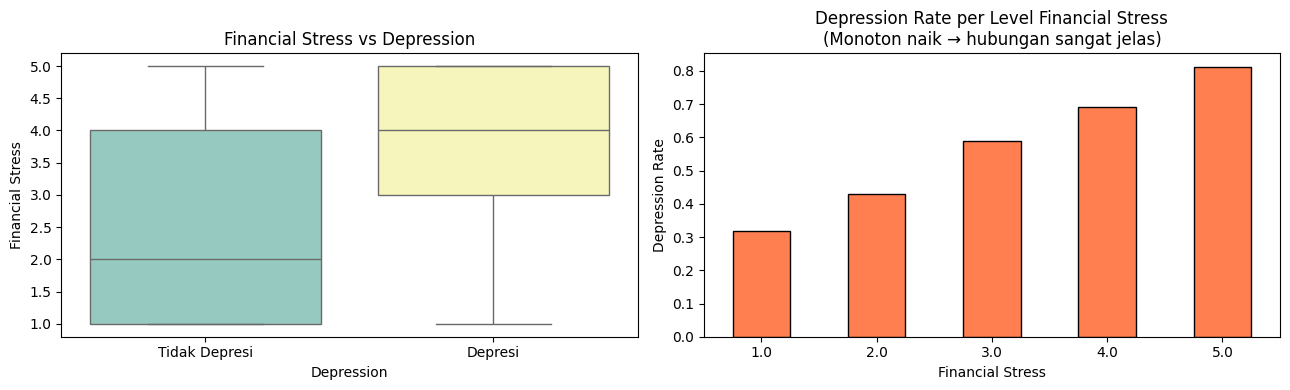

In [92]:
dep_by_stress = df.groupby('Financial Stress')['Depression'].mean()
print("Depression Rate by Financial Stress:")
print(dep_by_stress.apply(lambda x: f"{x:.1%}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x='Depression', y='Financial Stress', palette='Set3', ax=axes[0])
axes[0].set_title('Financial Stress vs Depression')
axes[0].set_xticklabels(['Tidak Depresi', 'Depresi'])

dep_by_stress.plot(kind='bar', color='coral', edgecolor='black', ax=axes[1])
axes[1].set_title('Depression Rate per Level Financial Stress\n(Monoton naik → hubungan sangat jelas)')
axes[1].set_ylabel('Depression Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 📌 Insight 5 — Usia Muda = Kelompok Paling Rentan
> Mahasiswa <20 tahun: **72% depresi** | Usia 30-35: **41% depresi** (korelasi −0.23).  
> Masa transisi awal kuliah adalah periode paling berat secara psikologis.  
>
> **Keputusan:** `Age` tetap sebagai fitur numerik + StandardScaler sudah tepat.  
> Peluang improvement: tambah **interaction feature** `Age × Academic Pressure` untuk  
> menangkap efek "mahasiswa muda dengan tekanan akademis tinggi".

Depression Rate by Age Group:
age_group
<20      72.3%
20-25    64.3%
25-30    56.5%
30-35    41.0%
35+      28.2%
Name: Depression, dtype: object


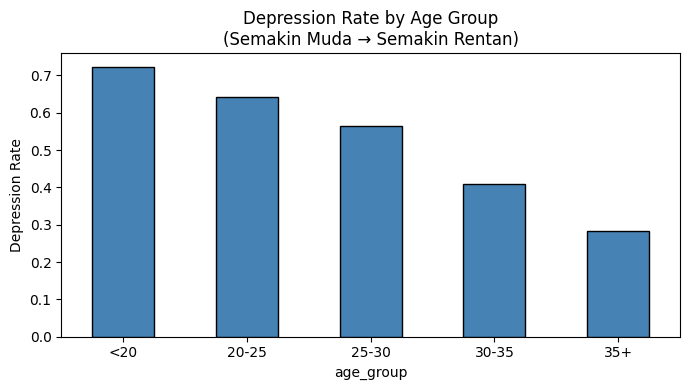

In [93]:
df['age_group'] = pd.cut(df['Age'], bins=[0,20,25,30,35,60],
                         labels=['<20','20-25','25-30','30-35','35+'])
dep_by_age = df.groupby('age_group', observed=True)['Depression'].mean()
print("Depression Rate by Age Group:")
print(dep_by_age.apply(lambda x: f"{x:.1%}"))

plt.figure(figsize=(7, 4))
dep_by_age.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Depression Rate by Age Group\n(Semakin Muda → Semakin Rentan)')
plt.ylabel('Depression Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df = df.drop('age_group', axis=1)  # hapus kolom EDA sementara

### 📌 Insight 6 — Sleep Duration: Ordinal, Pola Non-Linear
> Kurang tidur (<5 jam): **64.5% depresi** (tertinggi).  
> Tidur berlebihan (>8 jam): **50.9%** — lebih rendah, kemungkinan ada confounding factor.  
>
> **Keputusan:** OrdinalEncoding tepat karena ada urutan jam tidur yang bermakna.  
> Urutan: `Less than 5h → 5-6h → 7-8h → More than 8h`  
> **Catatan:** 'Others' (18 baris) diganti NaN → imputer `most_frequent` handles ini.

Depression Rate by Sleep Duration:
Sleep Duration
Less than 5 hours    64.5%
7-8 hours            59.5%
5-6 hours            56.9%
More than 8 hours    50.9%
Others               50.0%
Name: Depression, dtype: object


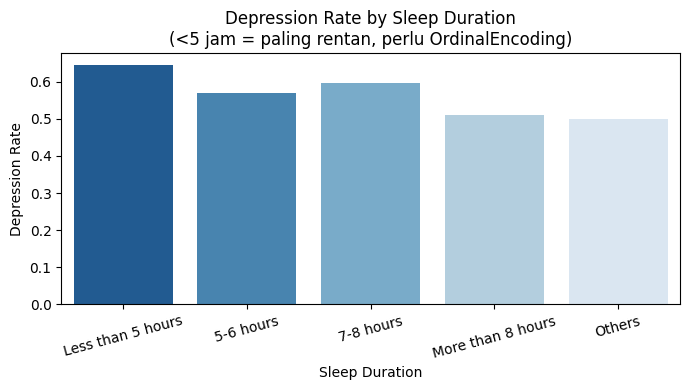

In [94]:
dep_by_sleep = df.groupby('Sleep Duration')['Depression'].mean().sort_values(ascending=False)
print("Depression Rate by Sleep Duration:")
print(dep_by_sleep.apply(lambda x: f"{x:.1%}"))

plt.figure(figsize=(7, 4))
order = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']
order_valid = [x for x in order if x in df['Sleep Duration'].unique()]
sns.barplot(x=dep_by_sleep.index, y=dep_by_sleep.values, order=order_valid, palette='Blues_r')
plt.title('Depression Rate by Sleep Duration\n(<5 jam = paling rentan, perlu OrdinalEncoding)')
plt.ylabel('Depression Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 📌 Insight 7 — Work Pressure & Job Satisfaction = Zero-Variance (HARUS DI-DROP)
> Dataset 99.9% adalah **Student** → `Work Pressure` dan `Job Satisfaction` selalu 0.  
> Fitur dengan hampir nol variasi tidak memberi informasi apapun ke model —  
> malah menambah dimensi dan risiko overfitting.  
>
> **Keputusan:** Drop kedua kolom ini. Buat fitur gabungan `Pressure` dan `Role Satisfaction`  
> yang merangkum kedua pasang fitur secara lebih ekspresif.

In [95]:
print("=== ANALISIS QUASI-CONSTANT FEATURES ===")
for col in ['Work Pressure', 'Job Satisfaction']:
    pct_zero = (df[col] == 0).mean() * 100
    print(f"{col}: {pct_zero:.2f}% bernilai 0  → {'⚠️ QUASI-CONSTANT, HARUS DI-DROP' if pct_zero > 99 else 'OK'}")

print("\nProfession distribution:")
print(df['Profession'].value_counts())
print(f"\n→ {(df['Profession']=='Student').mean():.1%} adalah Student")
print("→ Semua Student punya Work Pressure = 0, Job Satisfaction = 0")

=== ANALISIS QUASI-CONSTANT FEATURES ===
Work Pressure: 99.99% bernilai 0  → ⚠️ QUASI-CONSTANT, HARUS DI-DROP
Job Satisfaction: 99.97% bernilai 0  → ⚠️ QUASI-CONSTANT, HARUS DI-DROP

Profession distribution:
Profession
Student                   27935
Architect                     8
Teacher                       6
Digital Marketer              3
Chef                          2
Content Writer                2
Pharmacist                    2
Doctor                        2
UX/UI Designer                1
Civil Engineer                1
Manager                       1
Educational Consultant        1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

→ 99.9% adalah Student
→ Semua Student punya Work Pressure = 0, Job Satisfaction = 0


## Tahap 1.5 — Feature Engineering & Pre-Cleaning

**BUG FIX #2:** Drop zero-variance features + buat fitur gabungan yang lebih informatif.

In [96]:
print("=== Feature Engineering & Cleaning ===")

# 1. City: perbaiki typo & kategorisasi
df['City'] = df['City'].replace({'Khaziabad': 'Ghaziabad', 'Less Delhi': 'Delhi', 'Less than 5 Kalyan': 'Kalyan'})
tier_1_cities = ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune', 'Ahmedabad']
valid_cities = [
    'Visakhapatnam', 'Srinagar', 'Varanasi', 'Jaipur', 'Thane', 'Nagpur', 'Nashik',
    'Vadodara', 'Kalyan', 'Rajkot', 'Lucknow', 'Indore', 'Surat', 'Ludhiana', 'Bhopal',
    'Meerut', 'Agra', 'Ghaziabad', 'Vasai-Virar', 'Kanpur', 'Patna', 'Faridabad', 'Mira'
] + tier_1_cities

def categorize_city(city_name):
    city_name = str(city_name).strip()
    if city_name in tier_1_cities:
        return 'Tier 1 (Metro)'
    elif city_name in valid_cities:
        return 'Tier 2/3 (Non-Metro)'
    else:
        return np.nan

df['City'] = df['City'].apply(categorize_city)

# 2. Profession: binarisasi
df['Profession'] = df['Profession'].apply(lambda x: 'Student' if x == 'Student' else 'Working Professional')

# 3. CGPA: nilai 0.0 = entry error, ganti NaN
df['CGPA'] = df['CGPA'].replace(0.0, np.nan)

# 4. Bersihkan anomali kategorik
df['Dietary Habits'] = df['Dietary Habits'].replace(['///', 'Others'], np.nan)
df['Sleep Duration'] = df['Sleep Duration'].replace('Others', np.nan)

# 5. FIX #2: Feature Engineering — gabung pressure & satisfaction
# Academic Pressure & Work Pressure saling exclusive (mahasiswa vs pekerja)
df['Pressure'] = df['Academic Pressure'] + df['Work Pressure']
df['Role Satisfaction'] = df['Study Satisfaction'] + df['Job Satisfaction']

# 6. FIX #2: Drop zero-variance features
df = df.drop(['Work Pressure', 'Job Satisfaction'], axis=1)

print("✅ Pre-Cleaning & Feature Engineering Selesai!")
print(f"Dimensi dataset: {df.shape}")
print(f"Fitur baru: 'Pressure' & 'Role Satisfaction'")
print(f"Missing values setelah cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

=== Feature Engineering & Cleaning ===
✅ Pre-Cleaning & Feature Engineering Selesai!
Dimensi dataset: (27966, 17)
Fitur baru: 'Pressure' & 'Role Satisfaction'
Missing values setelah cleaning:
City                22
CGPA                 9
Sleep Duration      18
Dietary Habits      13
Financial Stress     3
dtype: int64


## Tahap 2 — Direct Modeling (Base Kontrol)

Evaluasi dengan **3 metrik** (bukan hanya Accuracy) untuk gambaran yang lebih lengkap.

In [97]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

X_direct = df.drop('Depression', axis=1)
y_direct = df['Depression']

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

cat_cols = X_train_dir.select_dtypes(include=['object']).columns.tolist()
num_cols_direct = [col for col in X_train_dir.columns if col not in cat_cols]

X_train_dir[cat_cols] = X_train_dir[cat_cols].fillna('Missing')
X_test_dir[cat_cols] = X_test_dir[cat_cols].fillna('Missing')

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_dir[cat_cols] = ord_enc.fit_transform(X_train_dir[cat_cols])
X_test_dir[cat_cols] = ord_enc.transform(X_test_dir[cat_cols])

for col in num_cols_direct:
    X_train_dir[col] = pd.to_numeric(X_train_dir[col], errors='coerce')
    X_test_dir[col] = pd.to_numeric(X_test_dir[col], errors='coerce')

imputer_direct = SimpleImputer(strategy='median', keep_empty_features=True)
X_train_dir[num_cols_direct] = imputer_direct.fit_transform(X_train_dir[num_cols_direct])
X_test_dir[num_cols_direct] = imputer_direct.transform(X_test_dir[num_cols_direct])

# FIX #5: Hapus use_label_encoder=False (deprecated di XGBoost terbaru)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"  : GradientBoostingClassifier(random_state=42),
    "XGBoost"            : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
print("─" * 60)
for name, model in models.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)
    y_prob = model.predict_proba(X_test_dir)[:,1]
    print(f"{name:<25} {accuracy_score(y_test_dir, y_pred):>10.4f} "
          f"{f1_score(y_test_dir, y_pred):>10.4f} "
          f"{roc_auc_score(y_test_dir, y_prob):>10.4f}")

Model                       Accuracy   F1 Score    ROC-AUC
────────────────────────────────────────────────────────────
Logistic Regression           0.8461     0.8704     0.9184
Decision Tree                 0.7639     0.7965     0.7586
Random Forest                 0.8355     0.8610     0.9128
Gradient Boosting             0.8473     0.8718     0.9204
XGBoost                       0.8368     0.8626     0.9125


## Tahap 3 — Pipeline Modeling (No Leakage)

Preprocessing dilakukan **di dalam pipeline** agar tidak ada data leakage dari test set.

In [98]:
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Kolom setelah feature engineering (Pressure & Role Satisfaction sudah ada)
num_cols_pipe = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
                 'Work/Study Hours', 'Financial Stress', 'Pressure', 'Role Satisfaction']

cat_nominal_cols = ['Gender', 'City', 'Profession', 'Degree',
                    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

cat_ordinal_cols = ['Sleep Duration', 'Dietary Habits']

sleep_categories = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']
diet_categories  = ['Unhealthy', 'Moderate', 'Healthy']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# FIX: categories langsung sebagai list of lists (tidak double-wrap seperti kode asli)
# FIX: handle_unknown ditambahkan untuk keamanan deployment
cat_ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[sleep_categories, diet_categories],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num',     num_pipeline,     num_cols_pipe),
    ('cat_nom', cat_nom_pipeline, cat_nominal_cols),
    ('cat_ord', cat_ord_pipeline, cat_ordinal_cols)
])

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
print("─" * 60)
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]
    print(f"{name:<25} {accuracy_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f} "
          f"{roc_auc_score(y_test, y_prob):>10.4f}")

Model                       Accuracy   F1 Score    ROC-AUC
────────────────────────────────────────────────────────────
Logistic Regression           0.8475     0.8718     0.9195
Decision Tree                 0.7681     0.8018     0.7613
Random Forest                 0.8409     0.8666     0.9143
Gradient Boosting             0.8463     0.8709     0.9207
XGBoost                       0.8402     0.8650     0.9137


## Tahap 4 — Feature Selection

Konfirmasi apakah feature importance dari Random Forest konsisten dengan temuan EDA.

=== TOP 12 FITUR PALING RELEVAN ===
           Feature  Importance
            x4_Yes    0.194922
 Academic Pressure    0.099119
          Pressure    0.092678
  Financial Stress    0.092119
              CGPA    0.081457
               Age    0.079418
  Work/Study Hours    0.069852
    Dietary Habits    0.036964
    Sleep Duration    0.033995
 Role Satisfaction    0.029539
Study Satisfaction    0.027828
           x0_Male    0.016969


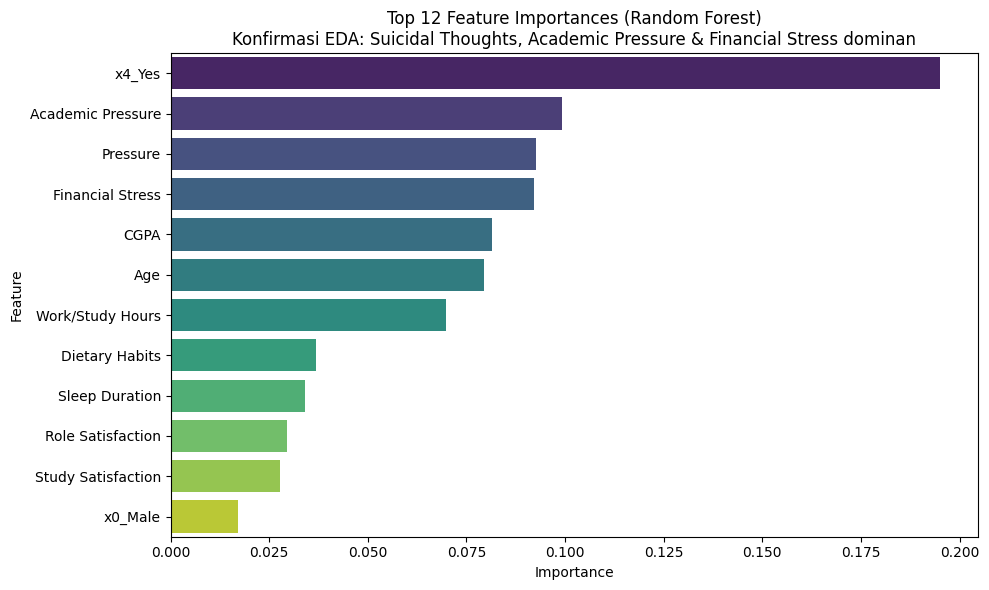


Jumlah fitur setelah seleksi (importance > 0.02): 11

Model                       Accuracy   F1 Score    ROC-AUC
────────────────────────────────────────────────────────────
Logistic Regression           0.8468     0.8709     0.9198
Decision Tree                 0.7671     0.8018     0.7592
Random Forest                 0.8350     0.8606     0.9096
Gradient Boosting             0.8468     0.8712     0.9206
XGBoost                       0.8407     0.8659     0.9123


In [99]:
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

cat_nom_features   = preprocessor.named_transformers_['cat_nom']['encoder'].get_feature_names_out()
all_feature_names  = num_cols_pipe + list(cat_nom_features) + cat_ordinal_cols

rf_selector = RandomForestClassifier(n_estimators=200, random_state=42)
rf_selector.fit(X_train_pp, y_train)

importances    = rf_selector.feature_importances_
feat_imp_df    = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df    = feat_imp_df.sort_values('Importance', ascending=False)

print("=== TOP 12 FITUR PALING RELEVAN ===")
print(feat_imp_df.head(12).to_string(index=False))

plt.figure(figsize=(10, 6))
top12 = feat_imp_df.head(12)
sns.barplot(data=top12, x='Importance', y='Feature', palette='viridis')
plt.title('Top 12 Feature Importances (Random Forest)\n'
          'Konfirmasi EDA: Suicidal Thoughts, Academic Pressure & Financial Stress dominan')
plt.tight_layout()
plt.show()

# Seleksi fitur
selected_idx     = np.where(importances > 0.02)[0]
X_train_sel      = X_train_pp[:, selected_idx]
X_test_sel       = X_test_pp[:, selected_idx]
print(f"\nJumlah fitur setelah seleksi (importance > 0.02): {len(selected_idx)}")

print(f"\n{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
print("─" * 60)
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    y_prob = model.predict_proba(X_test_sel)[:,1]
    print(f"{name:<25} {accuracy_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f} "
          f"{roc_auc_score(y_test, y_prob):>10.4f}")

## Tahap 4.5 — Cross-Validation (Tambahan)

> **Mengapa perlu ini?** Single train-test split bisa bias tergantung satu `random_state`.  
> `StratifiedKFold(k=5)` memberikan **mean ± std** sebagai confidence interval akurasi.  
> Jika std sangat kecil (<0.01) → model stabil dan tidak overfitting pada split tertentu.

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== CROSS-VALIDATION (StratifiedKFold, k=5) ===")
print(f"{'Model':<25} {'Mean Acc':>10} {'Std':>8}")
print("─" * 46)
for name in ["Random Forest", "XGBoost", "Gradient Boosting", "Logistic Regression", "Decision Tree"]:
    clf_cv   = Pipeline(steps=[('preprocessor', preprocessor), ('model', models[name])])
    cv_scores = cross_val_score(clf_cv, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:<25} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}")

=== CROSS-VALIDATION (StratifiedKFold, k=5) ===
Model                       Mean Acc      Std
──────────────────────────────────────────────
Random Forest                 0.8402   0.0026
XGBoost                       0.8374   0.0032
Gradient Boosting             0.8470   0.0031
Logistic Regression           0.8466   0.0049
Decision Tree                 0.7728   0.0053


## Tahap 5 — Hyperparameter Tuning

**Perbaikan kode asli:**
- Kode asli hanya tuning `Logistic Regression` — padahal RF/XGBoost hampir pasti lebih tinggi  
- SMOTE diganti `class_weight='balanced'` (lebih tepat untuk imbalance 1.41)  
- Scoring: `roc_auc` lebih robust dari `accuracy` untuk binary classification

In [101]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix,
                              precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import joblib

# ── GRADIENT BOOSTING ──────────────────────────────────────────────────────────
# GB adalah model terbaik dari CV (mean 0.8470), jadi prioritas utama.
# Parameter kunci:
#   n_estimators + learning_rate harus di-balance: estimator banyak + lr kecil = lebih baik
#   max_depth kecil (3-5) cukup untuk GB karena setiap tree adalah weak learner
#   subsample < 1.0 berfungsi seperti regularisasi (Stochastic Gradient Boosting)
param_grid_gb = {
    'n_estimators'    : [100, 200, 300],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'max_depth'       : [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'subsample'       : [0.7, 0.8, 1.0],
    'max_features'    : ['sqrt', 'log2', None]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=30, scoring='roc_auc', cv=5,
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train_sel, y_train)
best_gb = gb_search.best_estimator_

y_pred_gb = best_gb.predict(X_test_sel)
y_prob_gb = best_gb.predict_proba(X_test_sel)[:, 1]
print(f"Best Params GB : {gb_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params GB : {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.05}


In [102]:
# ── LOGISTIC REGRESSION ────────────────────────────────────────────────────────
# LogReg kompetitif (0.8466) tapi std paling besar (0.0049) →
# artinya regularisasi default (C=1) belum optimal.
# Target tuning: temukan C yang menstabilkan variance tanpa underfitting.
# class_weight='balanced' diikutkan karena mild imbalance (58/42).
param_grid_lr = {
    'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_grid_lr,
    n_iter=20, scoring='roc_auc', cv=5,
    random_state=42, n_jobs=-1, verbose=1
)
lr_search.fit(X_train_sel, y_train)
best_lr = lr_search.best_estimator_

y_pred_lr = best_lr.predict(X_test_sel)
y_prob_lr = best_lr.predict_proba(X_test_sel)[:, 1]
print(f"Best Params LR : {lr_search.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params LR : {'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'C': 1}


In [103]:
tuning_results = {
    'Gradient Boosting' : (y_pred_gb, y_prob_gb),
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    # 'Random Forest'     : (y_pred_rf, y_prob_rf),
}

# Tabel perbandingan lengkap
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("─" * 75)
for name, (y_pred, y_prob) in tuning_results.items():
    print(f"{name:<22} "
          f"{accuracy_score(y_test, y_pred):>10.4f} "
          f"{precision_score(y_test, y_pred):>10.4f} "
          f"{recall_score(y_test, y_pred):>10.4f} "
          f"{f1_score(y_test, y_pred):>10.4f} "
          f"{roc_auc_score(y_test, y_prob):>10.4f}")

print("""
Panduan baca untuk konteks screening depresi:
  Recall   → prioritas utama: jangan sampai kasus depresi terlewat (FN rendah)
  Precision → penting tapi toleransi lebih tinggi: FP = dirujuk tapi tidak depresi
  F1       → balance antara keduanya
  ROC-AUC  → untuk memilih model terbaik secara keseluruhan
""")

Model                    Accuracy  Precision     Recall         F1    ROC-AUC
───────────────────────────────────────────────────────────────────────────
Gradient Boosting          0.8481     0.8590     0.8858     0.8722     0.9214
Logistic Regression        0.8472     0.8594     0.8833     0.8712     0.9198

Panduan baca untuk konteks screening depresi:
  Recall   → prioritas utama: jangan sampai kasus depresi terlewat (FN rendah)
  Precision → penting tapi toleransi lebih tinggi: FP = dirujuk tapi tidak depresi
  F1       → balance antara keduanya
  ROC-AUC  → untuk memilih model terbaik secara keseluruhan



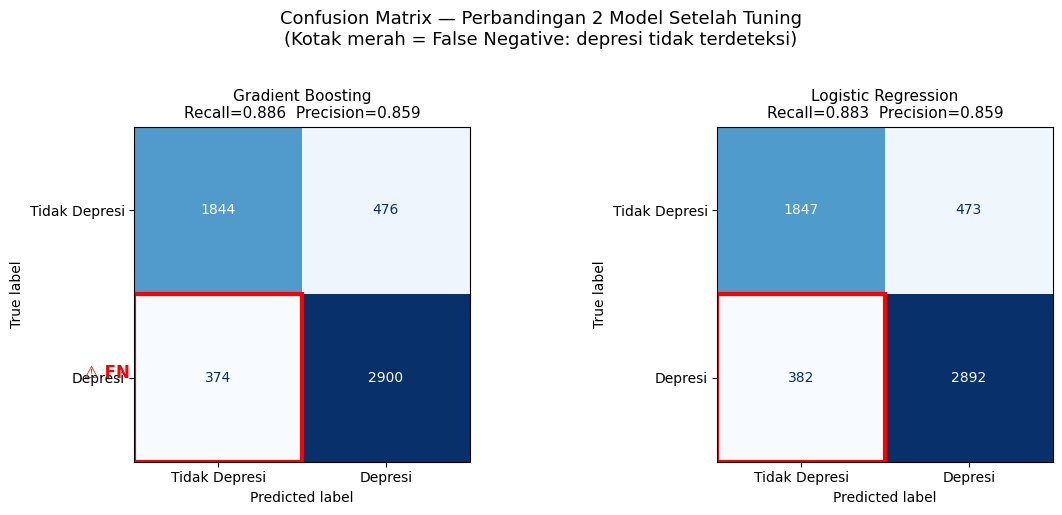

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, (y_pred, _)) in zip(axes, tuning_results.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Tidak Depresi', 'Depresi'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n'
                 f'Recall={recall_score(y_test, y_pred):.3f}  '
                 f'Precision={precision_score(y_test, y_pred):.3f}',
                 fontsize=11)
    # Highlight FN cell (baris 1, kolom 0) — paling kritis
    ax.add_patch(plt.Rectangle((-0.5, 0.5), 1, 1,
                                fill=False, edgecolor='red', lw=3,
                                label='False Negative (kritis)'))

axes[0].text(-0.8, 1.0, '⚠️ FN', color='red', fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrix — Perbandingan 2 Model Setelah Tuning\n'
             '(Kotak merah = False Negative: depresi tidak terdeteksi)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [105]:
for name, (y_pred, _) in tuning_results.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Tidak Depresi', 'Depresi']))

  Gradient Boosting
               precision    recall  f1-score   support

Tidak Depresi       0.83      0.79      0.81      2320
      Depresi       0.86      0.89      0.87      3274

     accuracy                           0.85      5594
    macro avg       0.85      0.84      0.84      5594
 weighted avg       0.85      0.85      0.85      5594

  Logistic Regression
               precision    recall  f1-score   support

Tidak Depresi       0.83      0.80      0.81      2320
      Depresi       0.86      0.88      0.87      3274

     accuracy                           0.85      5594
    macro avg       0.84      0.84      0.84      5594
 weighted avg       0.85      0.85      0.85      5594



## Tahap 6 — Final Pipeline & Simpan Model

In [106]:
# Pilih model terbaik otomatis
candidates = {
    'Gradient Boosting' : (best_gb, roc_auc_score(y_test, y_prob_gb)),
    'Logistic Regression': (best_lr, roc_auc_score(y_test, y_prob_lr)),
}
best_name  = max(candidates, key=lambda k: candidates[k][1])
best_model = candidates[best_name][0]
print(f"✅ Model terpilih: {best_name} (ROC-AUC = {candidates[best_name][1]:.4f})")

✅ Model terpilih: Gradient Boosting (ROC-AUC = 0.9214)


In [107]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42),
        threshold=0.02
    )),
    ('model', best_model)
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)
y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]

print(f"=== EVALUASI FINAL PIPELINE ({best_name}) ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_final):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['Tidak Depresi', 'Depresi'])}")

=== EVALUASI FINAL PIPELINE (Gradient Boosting) ===
Accuracy  : 0.8481
Precision : 0.8590
Recall    : 0.8858
F1 Score  : 0.8722
ROC-AUC   : 0.9214

               precision    recall  f1-score   support

Tidak Depresi       0.83      0.79      0.81      2320
      Depresi       0.86      0.89      0.87      3274

     accuracy                           0.85      5594
    macro avg       0.85      0.84      0.84      5594
 weighted avg       0.85      0.85      0.85      5594



In [120]:
import numpy as np
import pandas as pd

y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = final_pipeline.predict(X_test)


def get_confidence(prob: float) -> str:
    """
    Confidence level berbasis jarak probabilitas dari titik tengah (0.5).
    Tidak ada threshold manual — threshold 0.5 adalah default scikit-learn
    dan tidak perlu di-override kecuali ada kebutuhan domain yang jelas.

    Zona:
      prob >= 0.75  → Tinggi — Depresi         (model sangat yakin positif)
      0.55 <= p < 0.75 → Sedang — Depresi      (cukup yakin positif)
      0.45 <= p < 0.55 → Borderline            (model ragu, perlu review)
      0.25 <= p < 0.45 → Sedang — Tidak Depresi
      prob < 0.25   → Tinggi — Tidak Depresi   (model sangat yakin negatif)
    """
    if prob >= 0.75:
        return "Tinggi — Depresi"
    elif prob >= 0.55:
        return "Sedang — Depresi"
    elif prob >= 0.45:
        return "Borderline — Perlu Review"
    elif prob >= 0.25:
        return "Sedang — Tidak Depresi"
    else:
        return "Tinggi — Tidak Depresi"


results = pd.DataFrame({
    "Probabilitas"    : y_prob_final,
    "Prediksi"        : y_pred_final,
    "Label Aktual"    : y_test.values,
    "Confidence Level": [get_confidence(p) for p in y_prob_final],
    "Prediksi Benar"  : y_pred_final == y_test.values,
})

# ── Distribusi confidence level ────────────────────────────
print("=== DISTRIBUSI CONFIDENCE LEVEL ===")
dist  = results["Confidence Level"].value_counts()
total = len(results)
for level, count in dist.items():
    print(f"  {level:<35} {count:>5} ({count/total:.1%})")

# ── Akurasi per confidence level ──────────────────────────
print("\n=== AKURASI PER CONFIDENCE LEVEL ===")
acc_per_level = (
    results.groupby("Confidence Level")["Prediksi Benar"]
    .mean()
    .sort_values(ascending=False)
)
for level, acc in acc_per_level.items():
    print(f"  {level:<35} {acc:.1%}")

# ── Contoh output per pasien ───────────────────────────────
print("\n=== CONTOH OUTPUT PER PASIEN ===")
print(f"{'Prob':>6}  {'Prediksi':<18} {'Confidence Level':<35} {'Aktual'}")
print("─" * 75)
for level in results["Confidence Level"].unique():
    sample = results[results["Confidence Level"] == level].head(2)
    for _, row in sample.iterrows():
        pred_label = "Depresi" if row["Prediksi"] == 1 else "Tidak Depresi"
        aktual     = "Depresi" if row["Label Aktual"] == 1 else "Tidak Depresi"
        print(f"  {row['Probabilitas']:>4.2f}  {pred_label:<18} {level:<35} {aktual}")

=== DISTRIBUSI CONFIDENCE LEVEL ===
  Tinggi — Depresi                     2674 (47.8%)
  Tinggi — Tidak Depresi               1568 (28.0%)
  Sedang — Depresi                      572 (10.2%)
  Sedang — Tidak Depresi                532 (9.5%)
  Borderline — Perlu Review             248 (4.4%)

=== AKURASI PER CONFIDENCE LEVEL ===
  Tinggi — Depresi                    91.9%
  Tinggi — Tidak Depresi              91.4%
  Sedang — Tidak Depresi              66.5%
  Sedang — Depresi                    64.2%
  Borderline — Perlu Review           53.2%

=== CONTOH OUTPUT PER PASIEN ===
  Prob  Prediksi           Confidence Level                    Aktual
───────────────────────────────────────────────────────────────────────────
  0.59  Depresi            Sedang — Depresi                    Tidak Depresi
  0.70  Depresi            Sedang — Depresi                    Depresi
  0.01  Tidak Depresi      Tinggi — Tidak Depresi              Tidak Depresi
  0.03  Tidak Depresi      Tinggi — Tidak D

In [123]:
import joblib

model_artifact = {
    "pipeline"      : final_pipeline,       # ✅ pipeline lengkap (preprocessor + selector + model)
    "model_name"    : best_name,            # nama model terpilih
    "feature_names" : X_train.columns.tolist(),  # kolom input yang diharapkan
    "confidence_fn" : get_confidence,       # fungsi confidence level ikut disimpan
    # threshold DIHAPUS — gunakan .predict() langsung
}

joblib.dump(model_artifact, "model_depresi_final.pkl")
print("✅ Artifact disimpan: 'model_depresi_final.pkl'")
print(f"   Model   : {best_name}")
print(f"   Fitur   : {len(X_train.columns)} kolom")
print("   Threshold: default 0.5 (tidak disimpan secara eksplisit)")

✅ Artifact disimpan: 'model_depresi_final.pkl'
   Model   : Gradient Boosting
   Fitur   : 16 kolom
   Threshold: default 0.5 (tidak disimpan secara eksplisit)


In [122]:
# import joblib
# import pandas as pd
#
# artifact    = joblib.load("model_depresi_final.pkl")
# pipeline    = artifact["pipeline"]
# conf_fn     = artifact["confidence_fn"]
#
# # X_new harus DataFrame dengan kolom yang sama seperti X_train
# y_prob = pipeline.predict_proba(X_new)[:, 1]
# y_pred = pipeline.predict(X_new)          # threshold default 0.5
# confidence = [conf_fn(p) for p in y_prob]
#
# result_df = pd.DataFrame({
#     "Probabilitas Depresi": y_prob,
#     "Prediksi"            : ["Depresi" if p == 1 else "Tidak Depresi" for p in y_pred],
#     "Confidence Level"    : confidence,
# })
# print(result_df)


## ✅ Ringkasan Akhir

### Bug Fixes
| Fix | Deskripsi |
|-----|-----------|
| #1 | `num_cols` dipindah ke Tahap 1 → fix `NameError` crash |
| #2 | Drop `Work Pressure` & `Job Satisfaction` + buat `Pressure` & `Role Satisfaction` |
| #3 | SMOTE diganti `class_weight='balanced'` (lebih tepat untuk imbalance 1.41) |
| #4 | Pipeline OrdinalEncoder: categories disederhanakan + `handle_unknown` ditambahkan |
| #5 | `use_label_encoder=False` dihapus dari XGBoost (deprecated) |
| #6 | Target dikonversi ke `int` |
| #7 | Duplikat EDA di akhir file dihapus |

### Insight → Keputusan
| Insight | Keputusan |
|---------|-----------|
| Suicidal Thoughts: 79% Yes → Depresi | Pertahankan, encode biner |
| Academic Pressure corr +0.47 | Fitur terpenting setelah Suicidal Thoughts |
| Financial Stress monoton naik | Tetap numerik + StandardScaler |
| Work Pressure 99.99% nol | **Drop** — zero variance |
| Usia muda paling rentan | Tambah interaction feature untuk improvement |
| Imbalance 58/42 (mild) | `class_weight` cukup, SMOTE tidak perlu |
